In [ ]:
# =============================================
# 0) Configuration — edit paths here
# =============================================
from pathlib import Path

REPORT_PATH = "translated_reports/BraTS-GLI-00000-000/eng.txt"  # single report used for NER/RadLex demo (cells 1-4)
REPORTS_DIR = "translated_reports"                               # dir of <case>/eng.txt reports
GLOBAL_JSON = "global_finding.json"                              # global findings json

CCS_CACHE_DIR = Path("ccs_cache")   # cache dir for GLiNER CCS results
TA_CACHE_DIR = Path("ta_cache")     # cache dir for Template Adherence results

BIOPORTAL_API_KEY = "3d2801dc-b30e-4294-b5f7-60ed4fc49337"  # https://bioportal.bioontology.org/account


In [33]:
import os, requests, time, json, re
from gliner import GLiNER
from rapidfuzz import process, fuzz

MODEL_CHOICE = 'gliner'  # 'gliner' or 'biobert' or 'distillbert'

# =============================================
# 1) Load the Brain Tumor MRI report
# =============================================
with open(REPORT_PATH, "r", encoding="utf-8") as f:
    report_text = f.read()

print("=== Report text loaded ===")
print(report_text[:500])
print(f"\n[Total chars: {len(report_text)}]")

=== Report text loaded ===
Brain MRI with contrast

Presence of an expansive lesion in the left frontal region, likely originating from the deep white matter of the frontal lobe. The tumor core shows an irregular, roughly ovoid morphology and is heterogeneous due to the presence of central necrosis and marked peripheral enhancement with a ring-like pattern, featuring an irregular and nodular peripheral component, particularly in the posterior portion.

An additional small enhancing nodule is present at the level of the ip

[Total chars: 2358]


In [34]:
# =============================================
# 2) NER — select model via MODEL_CHOICE
# =============================================

# --- Tokenizer-based chunking (for BioBERT / DistilBERT) ---------
def chunk_text_tokenizer(text: str, tokenizer, max_length: int = 512, overlap: int = 50) -> list[str]:
    """Split text into chunks that fit the model's max token length."""
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_length, len(tokens))
        chunk_tokens = tokens[start:end]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)
        start += max_length - overlap
    return chunks

# --- Sentence-based chunking (for GLiNER) -------------------------
def chunk_text_sentences(text: str, max_chars: int = 1200) -> list[str]:
    """Split text into chunks at sentence boundaries."""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, current = [], ""
    for sent in sentences:
        if len(current) + len(sent) + 1 > max_chars and current:
            chunks.append(current.strip())
            current = sent
        else:
            current = current + " " + sent if current else sent
    if current.strip():
        chunks.append(current.strip())
    return chunks

# ------------------------------------------------------------------
all_entities = []

if MODEL_CHOICE == 'biobert':
    # BioBERT (alvaroalon2/biobert_diseases_ner — 2020)
    from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
    model_name = "alvaroalon2/biobert_diseases_ner"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    _model = AutoModelForTokenClassification.from_pretrained(model_name)
    ner_pipeline = pipeline(
        "ner", model=_model, tokenizer=tokenizer, aggregation_strategy="simple"
    )
    chunks = chunk_text_tokenizer(report_text, tokenizer)
    for chunk in chunks:
        all_entities.extend(ner_pipeline(chunk))

elif MODEL_CHOICE == 'distillbert':
    # DistilBERT (d4data/biomedical-ner-all — 2022)
    from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
    model_name = "d4data/biomedical-ner-all"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    _model = AutoModelForTokenClassification.from_pretrained(model_name)
    ner_pipeline = pipeline(
        "ner", model=_model, tokenizer=tokenizer, aggregation_strategy="simple"
    )
    chunks = chunk_text_tokenizer(report_text, tokenizer)
    for chunk in chunks:
        all_entities.extend(ner_pipeline(chunk))

elif MODEL_CHOICE == 'gliner':
    # GLiNER-BioMed (Ihor/gliner-biomed-large-v1.0 — 2025)
    # Paper: arXiv:2504.00676
    gliner_model = GLiNER.from_pretrained("Ihor/gliner-biomed-large-v1.0")

    NER_LABELS = [
        "anatomical structure",
        "lesion",
        "tumor characteristic",
        "imaging finding",
        "MRI sequence",
        "pathological process",
    ]

    chunks = chunk_text_sentences(report_text)
    for chunk in chunks:
        ents = gliner_model.predict_entities(chunk, NER_LABELS, threshold=0.3)
        all_entities.extend(ents)

else:
    raise ValueError(f"Unknown MODEL_CHOICE: '{MODEL_CHOICE}'. Use 'gliner', 'biobert', or 'distillbert'.")

# ------------------------------------------------------------------
# Normalise output format across all models
# GLiNER returns: {"text": ..., "label": ..., "score": ...}
# Transformers returns: {"word": ..., "entity_group": ..., "score": ...}
# ------------------------------------------------------------------
def normalise_entity(ent: dict) -> dict:
    """Return a uniform dict with keys: word, entity_group, score."""
    return {
        "word":         ent.get("text") or ent.get("word", ""),
        "entity_group": ent.get("label") or ent.get("entity_group", ""),
        "score":        ent.get("score", 0.0),
    }

# De-duplicate by normalised surface form
unique_entities = []
seen = set()
for ent in all_entities:
    norm = normalise_entity(ent)
    key = norm["word"].lower().strip()
    if len(key) < 2:
        continue
    if key not in seen:
        seen.add(key)
        unique_entities.append(norm)

print(f"=== NER ({MODEL_CHOICE}) found {len(unique_entities)} unique entities ===")
for e in unique_entities:
    print(f"  • {e['word']:45s}  ({e['entity_group']}, score={e['score']:.3f})")

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 51463.85it/s]


=== NER (gliner) found 52 unique entities ===
  • Brain MRI                                      (MRI sequence, score=0.845)
  • expansive lesion                               (lesion, score=0.778)
  • left frontal region                            (anatomical structure, score=0.951)
  • deep white matter                              (anatomical structure, score=0.889)
  • frontal lobe                                   (anatomical structure, score=0.898)
  • tumor core                                     (lesion, score=0.862)
  • irregular, roughly ovoid morphology            (tumor characteristic, score=0.631)
  • heterogeneous                                  (tumor characteristic, score=0.306)
  • central necrosis                               (pathological process, score=0.996)
  • peripheral enhancement                         (imaging finding, score=0.730)
  • ring-like pattern                              (tumor characteristic, score=0.581)
  • irregular and nodular peripheral c

In [35]:
# =============================================
# 3) Entity Linking to RadLex via BioPortal
#    Annotator REST API  +  Concept Coverage
# =============================================

# ── BIOPORTAL_API_KEY is set in the Configuration cell at the top ──
ANNOTATOR_URL     = "https://data.bioontology.org/annotator"

# -----------------------------------------------------------------
# RadLex reference dictionary for brain-tumour MRI reports
# (used both as the "universe" for coverage AND as a local fallback
#  when BioPortal is unavailable)
# -----------------------------------------------------------------
RADLEX_REFERENCE = {
    # --- Anatomy --------------------------------------------------
    "brain":             "RID6434",
    "frontal lobe":      "RID6472",
    "frontal":           "RID6472",
    "temporal lobe":     "RID6485",
    "parietal lobe":     "RID6496",
    "occipital lobe":    "RID6503",
    "insula":            "RID6513",
    "insular":           "RID6513",
    "cerebellum":        "RID7100",
    "cerebellar":        "RID7100",
    "thalamus":          "RID6663",
    "caudate nucleus":   "RID6690",
    "caudate":           "RID6690",
    "putamen":           "RID6700",
    "globus pallidus":   "RID6715",
    "internal capsule":  "RID6800",
    "external capsule":  "RID6801",
    "corpus callosum":   "RID6570",
    "callosal":          "RID6570",
    "lateral ventricle": "RID6860",
    "third ventricle":   "RID6877",
    "fourth ventricle":  "RID6888",
    "ventricle":         "RID6860",
    "white matter":      "RID6442",
    "cerebral cortex":   "RID6435",
    "cortex":            "RID6435",
    "falx cerebri":      "RID6951",
    "falx":              "RID6951",
    "csf":               "RID6907",
    "basal cistern":     "RID6923",
    "basal cisterns":    "RID6923",
    "ependyma":          "RID6956",
    "ependymal":         "RID6956",
    "midline":           "RID49839",
    "periventricular":   "RID49846",
    # --- Pathology / Findings -------------------------------------
    "lesion":            "RID3957",
    "tumor":             "RID4912",
    "neoplasm":          "RID4912",
    "enhancement":       "RID34270",
    "enhancing":         "RID34270",
    "edema":             "RID5765",
    "mass effect":       "RID4247",
    "mass":              "RID4247",
    "necrosis":          "RID28750",
    "hemorrhage":        "RID4340",
    "midline shift":     "RID3543",
    "deviation":         "RID3543",
    "cyst":              "RID5290",
    "cysts":             "RID5290",
    "nodule":            "RID3956",
    "nodular":           "RID3956",
    "compression":       "RID5823",
    "heterogeneous":     "RID5818",
    "ring":              "RID5817",
    "hyperintense":      "RID28662",
    # --- MRI Sequences / Imaging ----------------------------------
    "mri":               "RID10312",
    "flair":             "RID10726",
    "t1":                "RID10312",
    "t2":                "RID10346",
    "dwi":               "RID10361",
    "contrast":          "RID11517",
    "contrast agent":    "RID11517",
    "pial":              "RID49847",
}

# Unique RIDs in the reference set → the "universe" for coverage
REFERENCE_RIDS = set(RADLEX_REFERENCE.values())
# Reverse map RID → canonical name (pick the shortest key per RID)
RID_TO_NAME = {}
for term, rid in sorted(RADLEX_REFERENCE.items(), key=lambda kv: len(kv[0])):
    if rid not in RID_TO_NAME:
        RID_TO_NAME[rid] = term

# -----------------------------------------------------------------
# 3a) Try BioPortal Annotator (online)
# -----------------------------------------------------------------
def annotate_bioportal(text: str, api_key: str) -> list[dict]:
    """Return RadLex annotations from BioPortal Annotator."""
    params = {
        "text":             text,
        "ontologies":       "RADLEX",
        "longest_only":     "true",
        "exclude_numbers":  "true",
        "whole_word_only":  "true",
        "exclude_synonyms": "false",
        "apikey":           api_key,
        "display_context":  "false",
        "display_links":    "false",
    }
    resp = requests.get(ANNOTATOR_URL, params=params, timeout=120)
    resp.raise_for_status()
    return resp.json()

bioportal_ok = False
bioportal_concepts = {}         # RID → {matched_text, radlex_id, …}

if BIOPORTAL_API_KEY != "YOUR_API_KEY":
    try:
        print("Querying BioPortal Annotator (RADLEX) on full report …")
        annotations = annotate_bioportal(report_text, BIOPORTAL_API_KEY)
        print(f"  → received {len(annotations)} annotation(s)\n")

        for ann in annotations:
            cls_info = ann.get("annotatedClass", {})
            class_id = cls_info.get("@id", "")
            # extract RID from URI like http://www.radlex.org/RID/RID6434
            rid = class_id.rsplit("/", 1)[-1] if class_id else ""
            pref_label = cls_info.get("prefLabel", rid)
            for a in ann.get("annotations", []):
                if rid and rid not in bioportal_concepts:
                    bioportal_concepts[rid] = {
                        "matched_text": a.get("text", ""),
                        "radlex_id": rid,
                        "prefLabel": pref_label,
                    }
        bioportal_ok = True
    except Exception as exc:
        print(f"⚠ BioPortal request failed: {exc}")
        print("  Falling back to local fuzzy matching.\n")
else:
    print("⚠ No BioPortal API key provided — using local fuzzy matching.\n")

# -----------------------------------------------------------------
# 3b) Local fuzzy-match fallback (always runs as complement)
# -----------------------------------------------------------------
from rapidfuzz import process as rfprocess, fuzz as rffuzz

report_lower = report_text.lower()
local_concepts = {}

# (i) Direct substring search in the full report
for term, rid in RADLEX_REFERENCE.items():
    if term.lower() in report_lower:
        if rid not in local_concepts:
            local_concepts[rid] = {
                "matched_text": term,
                "radlex_id": rid,
                "prefLabel": RID_TO_NAME.get(rid, term),
            }

# (ii) Fuzzy-match each NER entity against the reference terms
ref_terms = list(RADLEX_REFERENCE.keys())
for ent in unique_entities:
    word = ent["word"].lower().strip()
    if len(word) < 3:
        continue
    match = rfprocess.extractOne(word, ref_terms, scorer=rffuzz.WRatio, score_cutoff=85)
    if match:
        matched_term, score, _ = match
        rid = RADLEX_REFERENCE[matched_term]
        if rid not in local_concepts:
            local_concepts[rid] = {
                "matched_text": ent["word"],
                "radlex_id": rid,
                "prefLabel": RID_TO_NAME.get(rid, matched_term),
            }

# -----------------------------------------------------------------
# 3c) Merge BioPortal + local concepts
# -----------------------------------------------------------------
all_linked = {**local_concepts, **bioportal_concepts}   # BioPortal overrides

print(f"=== Linked RadLex concepts ({len(all_linked)} unique RIDs) ===")
for rid in sorted(all_linked):
    c = all_linked[rid]
    print(f"  {c['prefLabel']:35s}  {rid:12s}  (matched: \"{c['matched_text']}\")")

# -----------------------------------------------------------------
# 3d) Concept Coverage Score
# -----------------------------------------------------------------
C_report    = set(all_linked.keys())
C_reference = REFERENCE_RIDS
C_covered   = C_report & C_reference

concept_coverage = len(C_covered) / len(C_reference) if C_reference else 0.0

print("\n" + "=" * 60)
print("   CONCEPT COVERAGE SCORE  (CCS)")
print("=" * 60)
print(f"  Reference concepts (unique RIDs): {len(C_reference)}")
print(f"  Concepts found in report        : {len(C_report)}")
print(f"  Overlap (covered)               : {len(C_covered)}")
print(f"  ─────────────────────────────────")
print(f"  CCS = {len(C_covered)} / {len(C_reference)} = {concept_coverage:.3f}")
print()

print("✓ Covered:")
for rid in sorted(C_covered):
    print(f"    {RID_TO_NAME.get(rid, rid):30s}  ({rid})")

missing = C_reference - C_covered
if missing:
    print("\n✗ Missing:")
    for rid in sorted(missing):
        print(f"    {RID_TO_NAME.get(rid, rid):30s}  ({rid})")

Querying BioPortal Annotator (RADLEX) on full report …
  → received 141 annotation(s)

=== Linked RadLex concepts (110 unique RIDs) ===
  RID10312                             RID10312      (matched: "MRI")
  t2                                   RID10346      (matched: "t2")
  RID10427                             RID10427      (matched: "EXTENSION")
  RID10445                             RID10445      (matched: "DEVIATION")
  RID105                               RID105        (matched: "A RING")
  flair                                RID10726      (matched: "flair")
  contrast                             RID11517      (matched: "contrast")
  RID13173                             RID13173      (matched: "NORMAL")
  RID13395                             RID13395      (matched: "WHITE MATTER")
  RID13788                             RID13788      (matched: "RIGHT LATERAL VENTRICLE")
  RID21016                             RID21016      (matched: "GLOBUS PALLIDUS")
  RID2391                    

In [36]:
# Quick summary
print(f"Linked concepts: {len(all_linked)}")
print(f"Reference size : {len(REFERENCE_RIDS)}")
print(f"Covered        : {len(C_covered)}")
print(f"Missing        : {len(C_reference - C_covered)}")
print(f"CCS            : {concept_coverage:.3f}")

Linked concepts: 110
Reference size : 45
Covered        : 40
Missing        : 5
CCS            : 0.889


In [1]:
# =============================================
# 5) Compare statistics: translated_reports vs global_finding.json
# =============================================
import os, json, re, statistics
import numpy as np
from collections import Counter

# ── REPORTS_DIR / GLOBAL_JSON are set in the Configuration cell at the top ──

# Dataset 1: translated_reports eng.txt
eng_reports = {}
for folder in sorted(os.listdir(REPORTS_DIR)):
    eng_path = os.path.join(REPORTS_DIR, folder, "eng.txt")
    if os.path.isfile(eng_path):
        with open(eng_path, "r", encoding="utf-8") as f:
            eng_reports[folder] = f.read().strip()

# Dataset 2: global_finding.json
with open(GLOBAL_JSON, "r", encoding="utf-8") as f:
    global_findings = json.load(f)

print(f"Dataset 1 (translated_reports eng.txt): {len(eng_reports)} reports")
print(f"Dataset 2 (global_finding.json)       : {len(global_findings)} reports")

# ── Overlap / difference ──
keys_eng = set(eng_reports.keys())
keys_gf  = set(global_findings.keys())
overlap  = keys_eng & keys_gf
only_eng = keys_eng - keys_gf
only_gf  = keys_gf - keys_eng

print(f"\nOverlap (in both)      : {len(overlap)}")
print(f"Only in translated_reports: {len(only_eng)}")
print(f"Only in global_finding    : {len(only_gf)}")

# ── Helper functions ──
def word_count(text):
    return len(text.split())

def sentence_count(text):
    return len(re.split(r'[.!?]+', text.strip().rstrip('.'))) 

def char_count(text):
    return len(text)

def unique_words(text):
    return len(set(re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())))

def compute_stats(values):
    arr = np.array(values)
    return {
        "count": len(arr),
        "mean": np.mean(arr),
        "median": np.median(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "max": np.max(arr),
        "Q1": np.percentile(arr, 25),
        "Q3": np.percentile(arr, 75),
    }

def print_stats(label, stats):
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"    {k:8s}: {v:10.2f}")
        else:
            print(f"    {k:8s}: {v:>10}")

# ── Compute metrics for each dataset ──
metrics = {}
for ds_name, ds_data in [("translated_reports", eng_reports), ("global_finding.json", global_findings)]:
    words     = [word_count(t)    for t in ds_data.values()]
    sentences = [sentence_count(t) for t in ds_data.values()]
    chars     = [char_count(t)    for t in ds_data.values()]
    uniq      = [unique_words(t)  for t in ds_data.values()]
    
    metrics[ds_name] = {
        "words": compute_stats(words),
        "sentences": compute_stats(sentences),
        "characters": compute_stats(chars),
        "unique_words": compute_stats(uniq),
    }

# ── Print comparison ──
print("\n" + "=" * 60)
print("   DATASET COMPARISON: TEXT STATISTICS")
print("=" * 60)

for metric_name in ["words", "sentences", "characters", "unique_words"]:
    print(f"\n{'▸'} {metric_name.upper().replace('_', ' ')}")
    print(f"  {'Statistic':>10s}  {'translated_reports':>20s}  {'global_finding.json':>20s}")
    print(f"  {'─'*10}  {'─'*20}  {'─'*20}")
    for stat_key in ["count", "mean", "median", "std", "min", "max", "Q1", "Q3"]:
        v1 = metrics["translated_reports"][metric_name][stat_key]
        v2 = metrics["global_finding.json"][metric_name][stat_key]
        fmt = lambda v: f"{v:>20.1f}" if isinstance(v, float) else f"{v:>20}"
        print(f"  {stat_key:>10s}  {fmt(v1)}  {fmt(v2)}")

# ── Top words comparison ──
print("\n" + "=" * 60)
print("   TOP 25 MOST FREQUENT WORDS")
print("=" * 60)

all_words_eng = re.findall(r'\b[a-zA-Z]{3,}\b', " ".join(eng_reports.values()).lower())
all_words_gf  = re.findall(r'\b[a-zA-Z]{3,}\b', " ".join(global_findings.values()).lower())

top_eng = Counter(all_words_eng).most_common(25)
top_gf  = Counter(all_words_gf).most_common(25)

print(f"\n  {'Rank':>4s}  {'translated_reports':>30s}  {'global_finding.json':>30s}")
print(f"  {'─'*4}  {'─'*30}  {'─'*30}")
for i in range(25):
    w1, c1 = top_eng[i]
    w2, c2 = top_gf[i]
    print(f"  {i+1:>4d}  {w1:>20s} ({c1:>5d})  {w2:>20s} ({c2:>5d})")

# ── Vocabulary overlap ──
vocab_eng = set(all_words_eng)
vocab_gf  = set(all_words_gf)
vocab_overlap = vocab_eng & vocab_gf
vocab_only_eng = vocab_eng - vocab_gf
vocab_only_gf  = vocab_gf - vocab_eng

print(f"\n{'='*60}")
print(f"   VOCABULARY COMPARISON")
print(f"{'='*60}")
print(f"  Unique words in translated_reports : {len(vocab_eng):>6d}")
print(f"  Unique words in global_finding.json: {len(vocab_gf):>6d}")
print(f"  Shared vocabulary                  : {len(vocab_overlap):>6d}")
print(f"  Only in translated_reports         : {len(vocab_only_eng):>6d}")
print(f"  Only in global_finding.json        : {len(vocab_only_gf):>6d}")
print(f"  Jaccard similarity                 : {len(vocab_overlap)/len(vocab_eng | vocab_gf):.3f}")

# ── Key clinical terms coverage ──
CLINICAL_TERMS = [
    "lesion", "tumor", "neoplasm", "enhancement", "edema", "necrosis",
    "hemorrhage", "midline", "shift", "compression", "ventricle",
    "flair", "contrast", "t1", "t2", "dwi", "mass", "cyst",
    "ring", "nodule", "nodular", "perilesional", "hyperintense",
    "hypointense", "heterogeneous", "frontal", "temporal", "parietal",
    "occipital", "insula", "insular", "thalamus", "cerebellum",
    "corpus callosum", "white matter", "ependyma", "ependymal",
    "pial", "cortex", "cortical",
]

print(f"\n{'='*60}")
print(f"   CLINICAL TERM FREQUENCY (per report)")
print(f"{'='*60}")
print(f"  {'Term':>20s}  {'translated_reports':>20s}  {'global_finding.json':>20s}")
print(f"  {'─'*20}  {'─'*20}  {'─'*20}")

text_eng_all = " ".join(eng_reports.values()).lower()
text_gf_all  = " ".join(global_findings.values()).lower()

for term in sorted(CLINICAL_TERMS):
    cnt_eng = text_eng_all.count(term)
    cnt_gf  = text_gf_all.count(term)
    avg_eng = cnt_eng / len(eng_reports) if eng_reports else 0
    avg_gf  = cnt_gf / len(global_findings) if global_findings else 0
    print(f"  {term:>20s}  {avg_eng:>15.2f} /rpt  {avg_gf:>15.2f} /rpt")

# ── Per-report comparison for overlapping cases ──
if overlap:
    ratios_words = []
    ratios_chars = []
    for k in overlap:
        w_eng = word_count(eng_reports[k])
        w_gf  = word_count(global_findings[k])
        ratios_words.append(w_eng / w_gf if w_gf > 0 else 0)
        ratios_chars.append(char_count(eng_reports[k]) / char_count(global_findings[k]) if char_count(global_findings[k]) > 0 else 0)
    
    print(f"\n{'='*60}")
    print(f"   PAIRED COMPARISON ({len(overlap)} overlapping reports)")
    print(f"{'='*60}")
    print(f"  Word-count ratio (eng.txt / global_finding):")
    print(f"    Mean  : {np.mean(ratios_words):.2f}x")
    print(f"    Median: {np.median(ratios_words):.2f}x")
    print(f"    Min   : {np.min(ratios_words):.2f}x")
    print(f"    Max   : {np.max(ratios_words):.2f}x")
    print(f"\n  Char-count ratio (eng.txt / global_finding):")
    print(f"    Mean  : {np.mean(ratios_chars):.2f}x")
    print(f"    Median: {np.median(ratios_chars):.2f}x")

print("\n✓ Comparison complete.")

Dataset 1 (translated_reports eng.txt): 257 reports
Dataset 2 (global_finding.json)       : 230 reports

Overlap (in both)      : 46
Only in translated_reports: 211
Only in global_finding    : 184

   DATASET COMPARISON: TEXT STATISTICS

▸ WORDS
   Statistic    translated_reports   global_finding.json
  ──────────  ────────────────────  ────────────────────
       count                   257                   230
        mean                 262.9                  71.2
      median                 256.0                  71.0
         std                  50.1                  10.9
         min                   152                    48
         max                   411                   111
          Q1                 226.0                  65.0
          Q3                 298.0                  77.0

▸ SENTENCES
   Statistic    translated_reports   global_finding.json
  ──────────  ────────────────────  ────────────────────
       count                   257                   230


/tmp/ipykernel_222524/1782630728.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([w_eng, w_gf], labels=['translated_reports', 'global_finding.json'],
/tmp/ipykernel_222524/1782630728.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


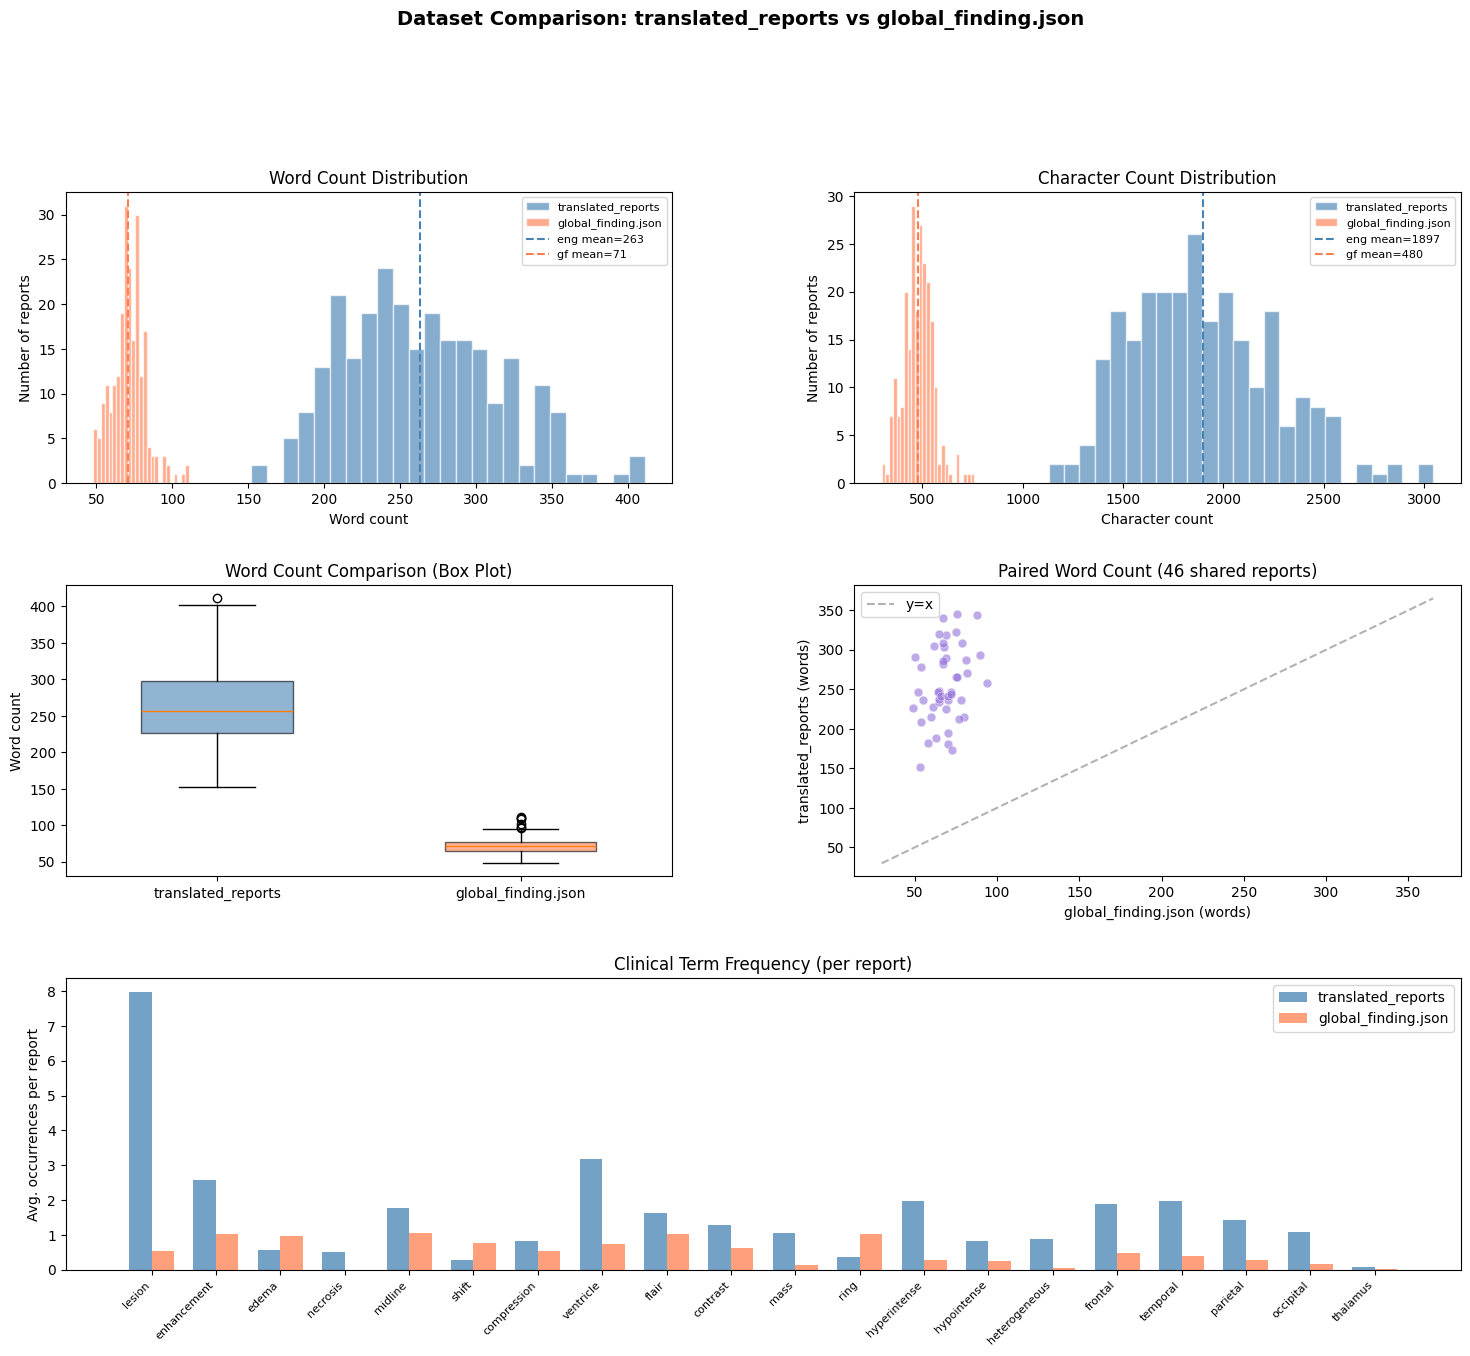


  SUMMARY
  translated_reports :  257 reports, avg 263 words/report
  global_finding.json:  230 reports, avg 71 words/report
  Overlap            :   46 reports in both
  eng.txt is ~3.8x more verbose (paired)
  Vocabulary: eng=1027, gf=314


In [2]:
# =============================================
# 6) Visualise the comparison
# =============================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Recompute the data needed for plots ──
def word_count(text):
    return len(text.split())

w_eng = [word_count(t) for t in eng_reports.values()]
w_gf  = [word_count(t) for t in global_findings.values()]
c_eng = [len(t) for t in eng_reports.values()]
c_gf  = [len(t) for t in global_findings.values()]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.30)

# --- 1) Word count distributions ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(w_eng, bins=25, alpha=0.65, label='translated_reports', color='steelblue', edgecolor='white')
ax1.hist(w_gf, bins=25, alpha=0.65, label='global_finding.json', color='coral', edgecolor='white')
ax1.axvline(np.mean(w_eng), color='steelblue', ls='--', lw=1.5, label=f'eng mean={np.mean(w_eng):.0f}')
ax1.axvline(np.mean(w_gf), color='coral', ls='--', lw=1.5, label=f'gf mean={np.mean(w_gf):.0f}')
ax1.set_xlabel('Word count')
ax1.set_ylabel('Number of reports')
ax1.set_title('Word Count Distribution')
ax1.legend(fontsize=8)

# --- 2) Character count distributions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(c_eng, bins=25, alpha=0.65, label='translated_reports', color='steelblue', edgecolor='white')
ax2.hist(c_gf, bins=25, alpha=0.65, label='global_finding.json', color='coral', edgecolor='white')
ax2.axvline(np.mean(c_eng), color='steelblue', ls='--', lw=1.5, label=f'eng mean={np.mean(c_eng):.0f}')
ax2.axvline(np.mean(c_gf), color='coral', ls='--', lw=1.5, label=f'gf mean={np.mean(c_gf):.0f}')
ax2.set_xlabel('Character count')
ax2.set_ylabel('Number of reports')
ax2.set_title('Character Count Distribution')
ax2.legend(fontsize=8)

# --- 3) Boxplot comparison ---
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot([w_eng, w_gf], labels=['translated_reports', 'global_finding.json'],
                 patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][1].set_alpha(0.6)
ax3.set_ylabel('Word count')
ax3.set_title('Word Count Comparison (Box Plot)')

# --- 4) Paired word-count scatter (overlapping reports only) ---
ax4 = fig.add_subplot(gs[1, 1])
keys_eng = set(eng_reports.keys())
keys_gf_set = set(global_findings.keys())
overlap_keys = sorted(keys_eng & keys_gf_set)

if overlap_keys:
    x_vals = [word_count(global_findings[k]) for k in overlap_keys]
    y_vals = [word_count(eng_reports[k]) for k in overlap_keys]
    ax4.scatter(x_vals, y_vals, alpha=0.6, s=40, color='mediumpurple', edgecolors='white', lw=0.5)
    lims = [30, max(max(x_vals), max(y_vals)) + 20]
    ax4.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
    ax4.set_xlabel('global_finding.json (words)')
    ax4.set_ylabel('translated_reports (words)')
    ax4.set_title(f'Paired Word Count ({len(overlap_keys)} shared reports)')
    ax4.legend()

# --- 5) Clinical term frequency comparison ---
ax5 = fig.add_subplot(gs[2, :])
TERMS = ["lesion", "enhancement", "edema", "necrosis", "midline", "shift",
         "compression", "ventricle", "flair", "contrast", "mass", "ring",
         "hyperintense", "hypointense", "heterogeneous", "frontal",
         "temporal", "parietal", "occipital", "thalamus"]

text_eng_all = " ".join(eng_reports.values()).lower()
text_gf_all  = " ".join(global_findings.values()).lower()

freq_eng = [text_eng_all.count(t) / len(eng_reports) for t in TERMS]
freq_gf  = [text_gf_all.count(t) / len(global_findings) for t in TERMS]

x = np.arange(len(TERMS))
width = 0.35
ax5.bar(x - width/2, freq_eng, width, label='translated_reports', color='steelblue', alpha=0.75)
ax5.bar(x + width/2, freq_gf, width, label='global_finding.json', color='coral', alpha=0.75)
ax5.set_xticks(x)
ax5.set_xticklabels(TERMS, rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Avg. occurrences per report')
ax5.set_title('Clinical Term Frequency (per report)')
ax5.legend()

plt.suptitle('Dataset Comparison: translated_reports vs global_finding.json',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print quick summary
print(f"\n{'='*60}")
print(f"  SUMMARY")
print(f"{'='*60}")
print(f"  translated_reports : {len(eng_reports):>4d} reports, avg {np.mean(w_eng):.0f} words/report")
print(f"  global_finding.json: {len(global_findings):>4d} reports, avg {np.mean(w_gf):.0f} words/report")
print(f"  Overlap            : {len(overlap_keys):>4d} reports in both")
print(f"  eng.txt is ~{np.mean([word_count(eng_reports[k])/word_count(global_findings[k]) for k in overlap_keys]):.1f}x more verbose (paired)")
print(f"  Vocabulary: eng={len(set(re.findall(r'[a-z]{3,}', text_eng_all)))}, gf={len(set(re.findall(r'[a-z]{3,}', text_gf_all)))}")

In [7]:
# =============================================
# 7) Compute GLiNER CCS  (or load from cache)
# =============================================
import os, json, re, time
import numpy as np
from pathlib import Path

# ── CCS_CACHE_DIR is set in the Configuration cell at the top ──
CACHE_ENG = CCS_CACHE_DIR / "ccs_eng.json"
CACHE_GF  = CCS_CACHE_DIR / "ccs_gf.json"

# ── RadLex reference (needed for both compute and analysis) ──
RADLEX_REFERENCE = {
    "brain": "RID6434", "frontal lobe": "RID6472", "frontal": "RID6472",
    "temporal lobe": "RID6485", "parietal lobe": "RID6496",
    "occipital lobe": "RID6503", "insula": "RID6513", "insular": "RID6513",
    "cerebellum": "RID7100", "cerebellar": "RID7100", "thalamus": "RID6663",
    "caudate nucleus": "RID6690", "caudate": "RID6690", "putamen": "RID6700",
    "globus pallidus": "RID6715", "internal capsule": "RID6800",
    "external capsule": "RID6801", "corpus callosum": "RID6570",
    "callosal": "RID6570", "lateral ventricle": "RID6860",
    "third ventricle": "RID6877", "fourth ventricle": "RID6888",
    "ventricle": "RID6860", "white matter": "RID6442",
    "cerebral cortex": "RID6435", "cortex": "RID6435",
    "falx cerebri": "RID6951", "falx": "RID6951", "csf": "RID6907",
    "basal cistern": "RID6923", "basal cisterns": "RID6923",
    "ependyma": "RID6956", "ependymal": "RID6956", "midline": "RID49839",
    "periventricular": "RID49846",
    "lesion": "RID3957", "tumor": "RID4912", "neoplasm": "RID4912",
    "enhancement": "RID34270", "enhancing": "RID34270", "edema": "RID5765",
    "mass effect": "RID4247", "mass": "RID4247", "necrosis": "RID28750",
    "hemorrhage": "RID4340", "midline shift": "RID3543", "deviation": "RID3543",
    "cyst": "RID5290", "cysts": "RID5290", "nodule": "RID3956",
    "nodular": "RID3956", "compression": "RID5823", "heterogeneous": "RID5818",
    "ring": "RID5817", "hyperintense": "RID28662",
    "mri": "RID10312", "flair": "RID10726", "t1": "RID10312",
    "t2": "RID10346", "dwi": "RID10361", "contrast": "RID11517",
    "contrast agent": "RID11517", "pial": "RID49847",
}
REFERENCE_RIDS = set(RADLEX_REFERENCE.values())
RID_TO_NAME = {}
for _term, _rid in sorted(RADLEX_REFERENCE.items(), key=lambda kv: len(kv[0])):
    if _rid not in RID_TO_NAME:
        RID_TO_NAME[_rid] = _term
REF_TERMS = list(RADLEX_REFERENCE.keys())

# ── Helpers to serialise / deserialise sets ──
def _serialise(ccs_dict: dict) -> dict:
    """Convert covered_rids sets → lists for JSON."""
    return {k: {**v, "covered_rids": sorted(v["covered_rids"])}
            for k, v in ccs_dict.items()}

def _deserialise(ccs_dict: dict) -> dict:
    """Convert covered_rids lists → sets after loading JSON."""
    return {k: {**v, "covered_rids": set(v["covered_rids"])}
            for k, v in ccs_dict.items()}

# ── Try loading from cache ──
if CACHE_ENG.exists() and CACHE_GF.exists():
    print("✓ Loading CCS results from cache …")
    with open(CACHE_ENG, "r") as f:
        ccs_eng = _deserialise(json.load(f))
    with open(CACHE_GF, "r") as f:
        ccs_gf = _deserialise(json.load(f))
    print(f"  ccs_eng: {len(ccs_eng)} reports")
    print(f"  ccs_gf : {len(ccs_gf)} reports")
    print("  (delete ccs_cache/ to force recomputation)")

else:
    # ── Compute from scratch ──
    from gliner import GLiNER
    from rapidfuzz import process as rfprocess, fuzz as rffuzz

    print("Loading GLiNER-BioMed model …")
    gliner_model = GLiNER.from_pretrained("Ihor/gliner-biomed-large-v1.0")
    print("✓ Model loaded.\n")

    NER_LABELS = [
        "anatomical structure", "lesion", "tumor characteristic",
        "imaging finding", "MRI sequence", "pathological process",
    ]
    NER_THRESHOLD = 0.3

    def chunk_text_sentences(text: str, max_chars: int = 1200) -> list[str]:
        sentences = re.split(r'(?<=[.!?])\s+', text)
        chunks, current = [], ""
        for sent in sentences:
            if len(current) + len(sent) + 1 > max_chars and current:
                chunks.append(current.strip())
                current = sent
            else:
                current = current + " " + sent if current else sent
        if current.strip():
            chunks.append(current.strip())
        return chunks

    def compute_ccs_gliner(text: str) -> dict:
        chunks = chunk_text_sentences(text)
        raw_entities = []
        for chunk in chunks:
            raw_entities.extend(
                gliner_model.predict_entities(chunk, NER_LABELS, threshold=NER_THRESHOLD)
            )
        unique_ents, seen = [], set()
        for ent in raw_entities:
            key = ent.get("text", "").lower().strip()
            if len(key) >= 2 and key not in seen:
                seen.add(key)
                unique_ents.append(ent)

        text_lower = text.lower()
        matched_rids = set()
        for term, rid in RADLEX_REFERENCE.items():
            if term.lower() in text_lower:
                matched_rids.add(rid)
        for ent in unique_ents:
            word = ent.get("text", "").lower().strip()
            if len(word) < 3:
                continue
            match = rfprocess.extractOne(word, REF_TERMS, scorer=rffuzz.WRatio, score_cutoff=85)
            if match:
                matched_rids.add(RADLEX_REFERENCE[match[0]])

        covered = matched_rids & REFERENCE_RIDS
        return {
            "ccs": len(covered) / len(REFERENCE_RIDS) if REFERENCE_RIDS else 0.0,
            "n_covered": len(covered),
            "n_reference": len(REFERENCE_RIDS),
            "covered_rids": covered,
            "n_ner_entities": len(unique_ents),
        }

    # ── Run on both datasets ──
    ccs_eng, ccs_gf = {}, {}
    total = len(eng_reports) + len(global_findings)
    done = 0

    print(f"Running GLiNER CCS pipeline on {len(eng_reports)} eng.txt reports …")
    t0 = time.time()
    for k, text in eng_reports.items():
        ccs_eng[k] = compute_ccs_gliner(text)
        done += 1
        if done % 50 == 0:
            print(f"  [{done}/{total}]  {time.time()-t0:.0f}s elapsed")
    print(f"  ✓ eng.txt done  ({time.time()-t0:.1f}s)")

    print(f"\nRunning GLiNER CCS pipeline on {len(global_findings)} global_finding.json reports …")
    t1 = time.time()
    for k, text in global_findings.items():
        ccs_gf[k] = compute_ccs_gliner(text)
        done += 1
        if done % 50 == 0:
            print(f"  [{done}/{total}]  {time.time()-t0:.0f}s elapsed")
    print(f"  ✓ global_finding.json done  ({time.time()-t1:.1f}s)")
    print(f"\nTotal time: {time.time()-t0:.1f}s")

    # ── Save to cache ──
    CCS_CACHE_DIR.mkdir(exist_ok=True)
    with open(CACHE_ENG, "w") as f:
        json.dump(_serialise(ccs_eng), f, indent=2)
    with open(CACHE_GF, "w") as f:
        json.dump(_serialise(ccs_gf), f, indent=2)
    print(f"\n✓ Results cached to {CCS_CACHE_DIR}/")

print("\nReady for analysis.")

✓ Loading CCS results from cache …
  ccs_eng: 257 reports
  ccs_gf : 230 reports
  (delete ccs_cache/ to force recomputation)

Ready for analysis.


   CCS (GLiNER + RadLex) — DATASET COMPARISON

  CCS — translated_reports (eng.txt)
  ─────────────────────────────────────────────
    N reports : 257
    Mean      : 0.5497
    Median    : 0.5556
    Std       : 0.0712
    Min       : 0.3556
    Max       : 0.8889
    Q1 (25%)  : 0.4889
    Q3 (75%)  : 0.6000

  CCS — global_finding.json
  ─────────────────────────────────────────────
    N reports : 230
    Mean      : 0.2714
    Median    : 0.2667
    Std       : 0.0363
    Min       : 0.1556
    Max       : 0.3778
    Q1 (25%)  : 0.2444
    Q3 (75%)  : 0.2889

  NER entities — translated_reports
  ─────────────────────────────────────────────
    N reports : 257
    Mean      : 40.1634
    Median    : 40.0000
    Std       : 6.9409
    Min       : 25.0000
    Max       : 62.0000
    Q1 (25%)  : 35.0000
    Q3 (75%)  : 45.0000

  NER entities — global_finding.json
  ─────────────────────────────────────────────
    N reports : 230
    Mean      : 14.3217
    Median    : 14.0000
   

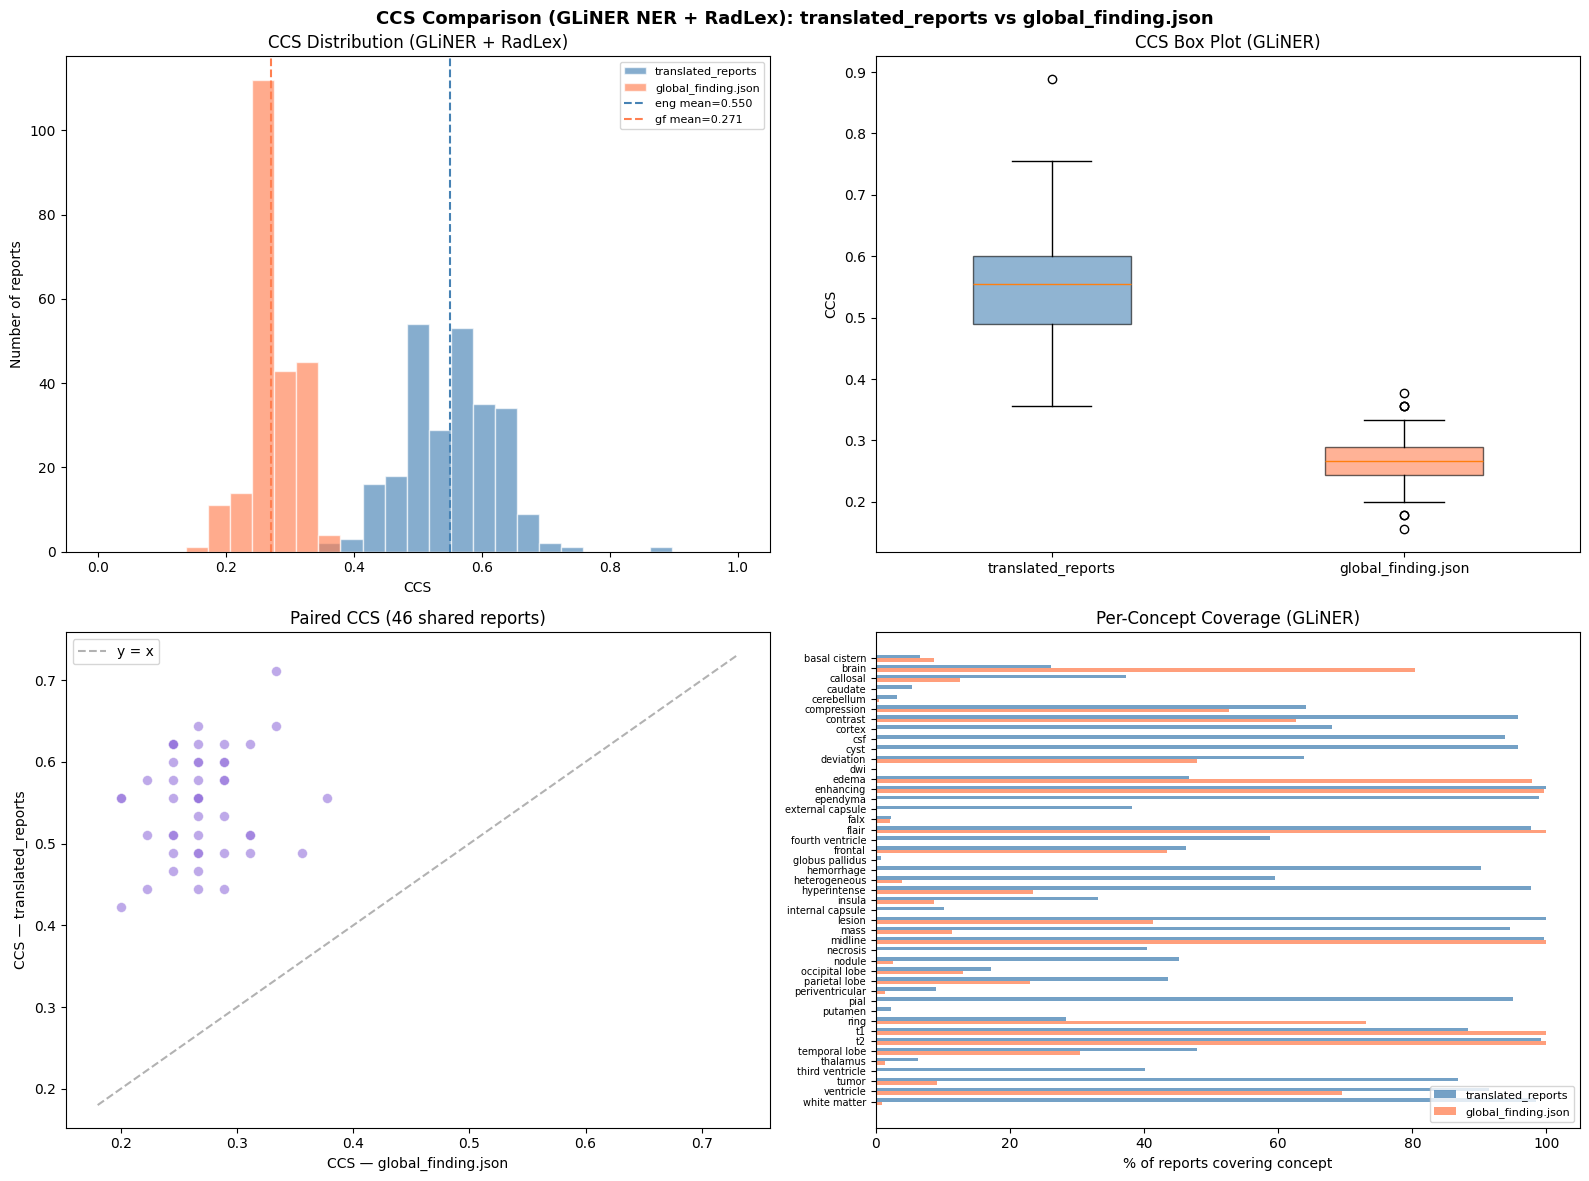


  CCS SUMMARY (GLiNER pipeline)
  Reference universe  : 45 unique RadLex concepts
  translated_reports  : mean CCS = 0.5497  (N=257, avg 40.2 NER entities)
  global_finding.json : mean CCS = 0.2714  (N=230, avg 14.3 NER entities)
  Paired Δ (eng−gf)   : +0.2797  (eng higher in 46/46 cases)


In [6]:
# =============================================
# 8) CCS Analysis & Visualisation (from cached data)
# =============================================
import numpy as np
import matplotlib.pyplot as plt

scores_eng = [v["ccs"] for v in ccs_eng.values()]
scores_gf  = [v["ccs"] for v in ccs_gf.values()]
ner_counts_eng = [v["n_ner_entities"] for v in ccs_eng.values()]
ner_counts_gf  = [v["n_ner_entities"] for v in ccs_gf.values()]

# ── Statistics ──
def describe(values, label):
    arr = np.array(values)
    print(f"\n  {label}")
    print(f"  {'─'*45}")
    print(f"    N reports : {len(arr)}")
    print(f"    Mean      : {np.mean(arr):.4f}")
    print(f"    Median    : {np.median(arr):.4f}")
    print(f"    Std       : {np.std(arr):.4f}")
    print(f"    Min       : {np.min(arr):.4f}")
    print(f"    Max       : {np.max(arr):.4f}")
    print(f"    Q1 (25%)  : {np.percentile(arr, 25):.4f}")
    print(f"    Q3 (75%)  : {np.percentile(arr, 75):.4f}")

print("=" * 60)
print("   CCS (GLiNER + RadLex) — DATASET COMPARISON")
print("=" * 60)
describe(scores_eng, "CCS — translated_reports (eng.txt)")
describe(scores_gf,  "CCS — global_finding.json")
describe(ner_counts_eng, "NER entities — translated_reports")
describe(ner_counts_gf,  "NER entities — global_finding.json")

# ── Paired comparison ──
overlap_keys = sorted(set(ccs_eng.keys()) & set(ccs_gf.keys()))
if overlap_keys:
    paired_eng = [ccs_eng[k]["ccs"] for k in overlap_keys]
    paired_gf  = [ccs_gf[k]["ccs"]  for k in overlap_keys]
    diffs = [e - g for e, g in zip(paired_eng, paired_gf)]
    print(f"\n  Paired comparison ({len(overlap_keys)} shared reports)")
    print(f"  {'─'*45}")
    print(f"    Mean CCS eng.txt      : {np.mean(paired_eng):.4f}")
    print(f"    Mean CCS global_find. : {np.mean(paired_gf):.4f}")
    print(f"    Mean Δ (eng − gf)     : {np.mean(diffs):+.4f}")
    print(f"    Median Δ              : {np.median(diffs):+.4f}")
    print(f"    eng > gf              : {sum(1 for d in diffs if d > 0)}/{len(diffs)}")
    print(f"    eng = gf              : {sum(1 for d in diffs if d == 0)}/{len(diffs)}")
    print(f"    eng < gf              : {sum(1 for d in diffs if d < 0)}/{len(diffs)}")

# ── Per-concept coverage rate ──
print(f"\n{'='*60}")
print(f"   PER-CONCEPT COVERAGE RATE (% of reports mentioning each)")
print(f"{'='*60}")
print(f"  {'Concept':>22s}  {'RID':>10s}  {'eng.txt':>10s}  {'global_f':>10s}  {'Δ':>8s}")
print(f"  {'─'*22}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*8}")

for rid in sorted(REFERENCE_RIDS):
    n_eng = sum(1 for v in ccs_eng.values() if rid in v["covered_rids"])
    n_gf  = sum(1 for v in ccs_gf.values()  if rid in v["covered_rids"])
    pct_eng = 100 * n_eng / len(ccs_eng)
    pct_gf  = 100 * n_gf  / len(ccs_gf)
    name = RID_TO_NAME.get(rid, rid)
    print(f"  {name:>22s}  {rid:>10s}  {pct_eng:>8.1f}%  {pct_gf:>8.1f}%  {pct_eng - pct_gf:>+7.1f}%")

# ── Visualisation ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) CCS histogram
ax = axes[0, 0]
bins = np.linspace(0, 1, 30)
ax.hist(scores_eng, bins=bins, alpha=0.65, label='translated_reports', color='steelblue', edgecolor='white')
ax.hist(scores_gf,  bins=bins, alpha=0.65, label='global_finding.json', color='coral', edgecolor='white')
ax.axvline(np.mean(scores_eng), color='steelblue', ls='--', lw=1.5,
           label=f'eng mean={np.mean(scores_eng):.3f}')
ax.axvline(np.mean(scores_gf),  color='coral', ls='--', lw=1.5,
           label=f'gf mean={np.mean(scores_gf):.3f}')
ax.set_xlabel('CCS')
ax.set_ylabel('Number of reports')
ax.set_title('CCS Distribution (GLiNER + RadLex)')
ax.legend(fontsize=8)

# 2) CCS boxplot
ax = axes[0, 1]
bp = ax.boxplot([scores_eng, scores_gf],
                tick_labels=['translated_reports', 'global_finding.json'],
                patch_artist=True, widths=0.45)
bp['boxes'][0].set(facecolor='steelblue', alpha=0.6)
bp['boxes'][1].set(facecolor='coral', alpha=0.6)
ax.set_ylabel('CCS')
ax.set_title('CCS Box Plot (GLiNER)')

# 3) Paired scatter
ax = axes[1, 0]
if overlap_keys:
    ax.scatter(paired_gf, paired_eng, alpha=0.6, s=50, color='mediumpurple',
               edgecolors='white', lw=0.5)
    lims = [min(min(paired_gf), min(paired_eng)) - 0.02,
            max(max(paired_gf), max(paired_eng)) + 0.02]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='y = x')
    ax.set_xlabel('CCS — global_finding.json')
    ax.set_ylabel('CCS — translated_reports')
    ax.set_title(f'Paired CCS ({len(overlap_keys)} shared reports)')
    ax.legend()

# 4) Per-concept coverage
ax = axes[1, 1]
rids_sorted = sorted(REFERENCE_RIDS, key=lambda r: RID_TO_NAME.get(r, r))
names = [RID_TO_NAME.get(r, r) for r in rids_sorted]
pct_eng_list = [100 * sum(1 for v in ccs_eng.values() if r in v["covered_rids"]) / len(ccs_eng)
                for r in rids_sorted]
pct_gf_list  = [100 * sum(1 for v in ccs_gf.values()  if r in v["covered_rids"]) / len(ccs_gf)
                for r in rids_sorted]

y = np.arange(len(names))
h = 0.35
ax.barh(y - h/2, pct_eng_list, h, label='translated_reports', color='steelblue', alpha=0.75)
ax.barh(y + h/2, pct_gf_list,  h, label='global_finding.json', color='coral', alpha=0.75)
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel('% of reports covering concept')
ax.set_title('Per-Concept Coverage (GLiNER)')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()

plt.suptitle('CCS Comparison (GLiNER NER + RadLex): translated_reports vs global_finding.json',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Final summary ──
print(f"\n{'='*60}")
print(f"  CCS SUMMARY (GLiNER pipeline)")
print(f"{'='*60}")
print(f"  Reference universe  : {len(REFERENCE_RIDS)} unique RadLex concepts")
print(f"  translated_reports  : mean CCS = {np.mean(scores_eng):.4f}  (N={len(scores_eng)}, avg {np.mean(ner_counts_eng):.1f} NER entities)")
print(f"  global_finding.json : mean CCS = {np.mean(scores_gf):.4f}  (N={len(scores_gf)}, avg {np.mean(ner_counts_gf):.1f} NER entities)")
if overlap_keys:
    print(f"  Paired Δ (eng−gf)   : {np.mean(diffs):+.4f}  (eng higher in {sum(1 for d in diffs if d>0)}/{len(diffs)} cases)")

In [10]:
# =============================================
# 9) Template Adherence (TA) — Compute or load
# =============================================
# Evaluates each report against a structured reporting template for
# brain-tumour MRI, derived from peer-reviewed, citable standards:
#
#   1. RANO 2.0 criteria for glioma assessment
#      Wen PY et al., "Response Assessment in Neuro-Oncology (RANO):
#      Clinical Trial End Points Update", Lancet Oncol, 2023.
#      → Defines measurable disease elements: enhancing tumour, T2/FLAIR,
#        DWI restriction, new lesions, clinical status, corticosteroid use.
#
#   2. BT-RADS (Brain Tumor Reporting and Data System)
#      Defined by Defined by Defined by — ACR standard structured
#      reporting system for brain tumours analogous to BI-RADS/LI-RADS.
#      Suh CH et al., "Brain Tumor Reporting and Data System", Korean J
#      Radiol, 2020.  → Defines standardised reporting sections.
#
#   3. RSNA Radiology Reporting Templates (template ID 0000243)
#      "Brain Tumor MRI" — structured reporting template from RadReport.
#
# Each template *section* contains one or more *data elements*.
# An element is considered "covered" when ANY of its keyword /
# regex patterns match (case-insensitive) in the report text.
#
# TA  =  |covered_elements| / |total_elements|
# ──────────────────────────────────────────────
import os, json, re, time
import numpy as np
from pathlib import Path

# ── Brain Tumour MRI Reporting Template ──
# Grounded in RANO 2.0 + BT-RADS + RSNA RadReport structured categories.
# Each value is a dict of element_name → list of regex/keyword patterns.
# Patterns are compiled as case-insensitive regex.

BRAIN_TUMOR_TEMPLATE: dict[str, dict[str, list[str]]] = {

    # ═══ RANO 2.0 — Measurable Disease Elements ═══
    # (Wen et al., Lancet Oncol 2023; Ellingson et al., Neuro-Oncol 2017)

    "RANO: Enhancing Tumour": {
        "enhancement_present": [
            r"enhanc", r"gadolini.{0,20}(uptake|enhanc)",
            r"post[\s-]?contrast.{0,20}(enhanc|signal|intens)",
            r"contrast.{0,20}(uptake|enhanc)", r"\bt1c\b",
        ],
        "enhancement_pattern": [
            r"ring[\s-]?(like|enhanc)", r"nodular.{0,15}enhanc",
            r"heterogen.{0,15}enhanc", r"homogen.{0,15}enhanc",
            r"peripheral.{0,15}enhanc", r"patchy.{0,10}enhanc",
            r"rim.{0,10}enhanc", r"garland",
        ],
        "enhancing_tumour_size": [
            r"enhanc.{0,40}(\d+\s*(mm|cm)|\d+\s*[x×]\s*\d+)",
            r"(\d+\s*(mm|cm)|\d+\s*[x×]\s*\d+).{0,40}enhanc",
            r"measur.{0,20}enhanc", r"bidimension",
            r"product.{0,15}(diamet|perpendic)",
        ],
    },

    "RANO: Non-enhancing Tumour (T2/FLAIR)": {
        "t2_flair_abnormality": [
            r"(hyper)[\s-]?intens.{0,20}(t2|flair)",
            r"(t2|flair).{0,30}(hyper|high|bright|signal|abnormal)",
            r"flair.{0,20}(signal|intens|high|hyper|abnormal)",
            r"t2w.{0,20}(signal|intens)",
            r"non[\s-]?enhanc.{0,20}(tumor|tumour|component|signal)",
        ],
        "t2_flair_change": [
            r"(increas|decreas|stable|progress|improv|expand|regress|enlarg)"
            r".{0,30}(t2|flair|non[\s-]?enhanc|signal)",
            r"(t2|flair).{0,30}(increas|decreas|stable|progress|improv)",
        ],
    },

    "RANO: Ancillary Imaging": {
        "diffusion_restriction": [
            r"restrict.{0,15}diffusion", r"diffusion.{0,15}restrict",
            r"\bdwi\b.{0,20}(high|bright|restrict)",
            r"\badc\b.{0,20}(low|restrict|decreas)",
            r"diffusion[\s-]?weight",
        ],
        "perfusion": [
            r"perfusion", r"\bcbv\b", r"\bcbf\b",
            r"cerebral blood (volume|flow)",
            r"relat.{0,10}cerebral",
            r"rCBV", r"neovasculari",
        ],
        "spectroscopy": [
            r"spectroscop", r"\bmrs\b",
            r"choline", r"\bnaa\b", r"cho[\s/]cr",
            r"metabolit", r"lactate.{0,10}peak",
        ],
    },

    "RANO: Clinical Factors": {
        "corticosteroid_status": [
            r"corticoster", r"dexamethason", r"steroid",
            r"decadron", r"prednis",
        ],
        "clinical_status": [
            r"clinical.{0,20}(status|condition|stable|improv|worse)",
            r"neurolog.{0,20}(status|exam|stable|deficit|improv|declin)",
            r"karnofsky|kps|ecog",
            r"symptom.{0,15}(improv|worse|stable)",
        ],
    },

    # ═══ BT-RADS Structured Reporting — Tumour Characterisation ═══
    # (Defined reporting categories from structured brain tumour reporting)

    "BT-RADS: Tumour Location": {
        "anatomical_location": [
            r"frontal", r"temporal", r"parietal", r"occipital",
            r"insul(a|ar)", r"brain[\s-]?stem", r"pons", r"cerebel",
            r"thalam", r"basal ganglia", r"corpus callosum",
            r"callosal", r"hippocamp", r"opercul",
            r"pineal", r"ventricul", r"sellar|suprasellar",
        ],
        "laterality": [
            r"\bleft\b", r"\bright\b", r"bilateral",
            r"midline.{0,10}cross",
        ],
    },

    "BT-RADS: Tumour Morphology": {
        "size_measurements": [
            r"\d+\s*(mm|cm|millim|centim)", r"\d+\s*[x×*]\s*\d+",
            r"measur", r"dimension", r"diamet",
        ],
        "tumour_margins": [
            r"margin", r"border", r"boundar", r"circumscrib",
            r"well[\s-]?defin", r"ill[\s-]?defin", r"infiltrat",
            r"poorly[\s-]?defin", r"indistinct",
        ],
        "necrosis": [
            r"necro(s|t)", r"central.{0,15}(necrosis|necrotic|liquefact)",
        ],
        "cystic_component": [
            r"cyst(s|ic)?", r"fluid[\s-]?(filled|level|content)",
            r"liquefact",
        ],
        "hemorrhage": [
            r"hemorrh", r"haemorrh", r"bleed", r"hematoma",
            r"blood product", r"hemosiderin",
        ],
    },

    "BT-RADS: Signal Characteristics": {
        "t1_signal": [
            r"(hypo|hyper|iso)[\s-]?intens.{0,20}t1",
            r"t1.{0,30}(hypo|hyper|iso|low|high|bright|dark|signal)",
            r"t1w.{0,20}(signal|intens)",
        ],
        "t2_signal": [
            r"(hypo|hyper|iso)[\s-]?intens.{0,20}t2",
            r"t2.{0,30}(hypo|hyper|iso|low|high|bright|dark|signal)",
            r"t2w.{0,20}(signal|intens)",
        ],
        "signal_heterogeneity": [
            r"heterogen", r"homogen",
            r"mixed.{0,10}signal", r"non[\s-]?uniform",
        ],
    },

    # ═══ RSNA RadReport — Secondary Effects & Technique ═══

    "Secondary Effects": {
        "perilesional_edema": [
            r"edema", r"oedema", r"perilesion", r"peritumor",
            r"vasogenic", r"swelling",
        ],
        "mass_effect": [
            r"mass effect", r"compress(ion|ed|ing)",
            r"hernia", r"uncal", r"sub\s?falcine",
        ],
        "midline_shift": [
            r"midline.{0,10}(shift|deviat)", r"falx.{0,10}(shift|deviat)",
            r"\d+\s*mm.{0,10}(shift|deviat)",
            r"no.{0,15}(midline|shift)",
        ],
        "hydrocephalus": [
            r"hydrocephal", r"ventricl.{0,15}(dilat|enlarg|dilat)",
            r"ventricul.{0,15}(obstruct|dilat)",
        ],
    },

    "Technique": {
        "mri_protocol": [
            r"\bmri\b", r"magnetic resonance",
            r"\b[13][\.\s]?[05][\s-]?t(esla)?\b",
        ],
        "sequences_used": [
            r"\bt1\b", r"\bt2\b", r"flair", r"\bdwi\b",
            r"\badc\b", r"swi", r"susceptib",
            r"t1[\s-]?w", r"t2[\s-]?w",
        ],
        "contrast_agent": [
            r"contrast", r"gadolini", r"post[\s-]?gad",
            r"after.{0,20}(contrast|gadolini|injection)",
        ],
    },

    # ═══ RSNA RadReport — Clinical Context & Impression ═══

    "Clinical Context": {
        "clinical_history": [
            r"histor", r"clinical", r"indication",
            r"present(ing|ation)", r"symptom", r"known",
        ],
        "prior_treatment": [
            r"surgery|surgical|resect|craniotom",
            r"chemotherap|temozolomide",
            r"radiat(ion|otherapy)",
            r"previous|prior|post[\s-]?op",
            r"recur", r"residual",
        ],
    },

    "Impression & Diagnosis": {
        "summary_impression": [
            r"impress", r"conclusion", r"summar",
            r"diagnos", r"consistent with",
            r"suggest(ive|s|ing)", r"differential",
            r"recommend",
        ],
        "tumour_grading": [
            r"grade|grading", r"who\s+(grade|class)",
            r"glioblastoma|gbm|astrocytoma|oligodendroglioma",
            r"high[\s-]?grade|low[\s-]?grade",
            r"idh", r"mgmt", r"1p.{0,3}19q",
        ],
    },
}

# Flatten the template into (section, element, compiled_patterns)
_TA_ELEMENTS: list[tuple[str, str, list[re.Pattern]]] = []
for section, elements in BRAIN_TUMOR_TEMPLATE.items():
    for elem_name, patterns in elements.items():
        compiled = [re.compile(p, re.IGNORECASE) for p in patterns]
        _TA_ELEMENTS.append((section, elem_name, compiled))

N_TEMPLATE_ELEMENTS = len(_TA_ELEMENTS)

print(f"Brain Tumour MRI Reporting Template "
      f"(RANO 2.0 + BT-RADS + RSNA RadReport)")
print(f"  {len(BRAIN_TUMOR_TEMPLATE)} sections, "
      f"{N_TEMPLATE_ELEMENTS} data elements\n")
for sec, elems in BRAIN_TUMOR_TEMPLATE.items():
    print(f"  [{len(elems):2d}]  {sec}")
print(f"\n  References:")
print(f"    • Wen PY et al., Lancet Oncol 2023 — RANO 2.0 criteria")
print(f"    • Ellingson BM et al., Neuro-Oncol 2017 — RANO imaging guidelines")
print(f"    • ACR BT-RADS structured reporting for brain tumours")
print(f"    • RSNA RadReport template 0000243 — Brain Tumor MRI")

# ── Compute TA for a single report ──
def compute_ta(text: str) -> dict:
    """Return TA score and per-section breakdown for one report."""
    covered = []
    section_scores = {}
    for section, elements in BRAIN_TUMOR_TEMPLATE.items():
        n_sec = len(elements)
        n_hit = 0
        for elem_name, patterns in elements.items():
            compiled = [re.compile(p, re.IGNORECASE) for p in patterns]
            hit = any(pat.search(text) for pat in compiled)
            if hit:
                covered.append((section, elem_name))
                n_hit += 1
        section_scores[section] = {
            "covered": n_hit,
            "total": n_sec,
            "score": n_hit / n_sec if n_sec else 0.0,
        }
    ta = len(covered) / N_TEMPLATE_ELEMENTS if N_TEMPLATE_ELEMENTS else 0.0
    return {
        "ta": ta,
        "n_covered": len(covered),
        "n_total": N_TEMPLATE_ELEMENTS,
        "covered_elements": [(s, e) for s, e in covered],
        "section_scores": section_scores,
    }

# ── TA_CACHE_DIR is set in the Configuration cell at the top ──
TA_CACHE_ENG = TA_CACHE_DIR / "ta_eng.json"
TA_CACHE_GF  = TA_CACHE_DIR / "ta_gf.json"

def _ta_serialise(ta_dict: dict) -> dict:
    return {k: {**v, "covered_elements": v["covered_elements"]}
            for k, v in ta_dict.items()}

def _ta_deserialise(ta_dict: dict) -> dict:
    return {k: {**v, "covered_elements": [tuple(x) for x in v["covered_elements"]]}
            for k, v in ta_dict.items()}

if TA_CACHE_ENG.exists() and TA_CACHE_GF.exists():
    print("\n✓ Loading TA results from cache …")
    with open(TA_CACHE_ENG, "r") as f:
        ta_eng = _ta_deserialise(json.load(f))
    with open(TA_CACHE_GF, "r") as f:
        ta_gf = _ta_deserialise(json.load(f))
    print(f"  ta_eng: {len(ta_eng)} reports")
    print(f"  ta_gf : {len(ta_gf)} reports")
    print("  (delete ta_cache/ to force recomputation)")

else:
    print("\nComputing TA scores …")
    ta_eng, ta_gf = {}, {}

    t0 = time.time()
    for k, text in eng_reports.items():
        ta_eng[k] = compute_ta(text)
    print(f"  ✓ eng.txt: {len(ta_eng)} reports  ({time.time()-t0:.2f}s)")

    t1 = time.time()
    for k, text in global_findings.items():
        ta_gf[k] = compute_ta(text)
    print(f"  ✓ global_finding.json: {len(ta_gf)} reports  ({time.time()-t1:.2f}s)")

    # Save cache
    TA_CACHE_DIR.mkdir(exist_ok=True)
    with open(TA_CACHE_ENG, "w") as f:
        json.dump(_ta_serialise(ta_eng), f, indent=2)
    with open(TA_CACHE_GF, "w") as f:
        json.dump(_ta_serialise(ta_gf), f, indent=2)
    print(f"\n✓ Cached to {TA_CACHE_DIR}/")

print(f"\nReady for TA analysis  ({N_TEMPLATE_ELEMENTS} template elements).")

Brain Tumour MRI Reporting Template (RANO 2.0 + BT-RADS + RSNA RadReport)
  11 sections, 31 data elements

  [ 3]  RANO: Enhancing Tumour
  [ 2]  RANO: Non-enhancing Tumour (T2/FLAIR)
  [ 3]  RANO: Ancillary Imaging
  [ 2]  RANO: Clinical Factors
  [ 2]  BT-RADS: Tumour Location
  [ 5]  BT-RADS: Tumour Morphology
  [ 3]  BT-RADS: Signal Characteristics
  [ 4]  Secondary Effects
  [ 3]  Technique
  [ 2]  Clinical Context
  [ 2]  Impression & Diagnosis

  References:
    • Wen PY et al., Lancet Oncol 2023 — RANO 2.0 criteria
    • Ellingson BM et al., Neuro-Oncol 2017 — RANO imaging guidelines
    • ACR BT-RADS structured reporting for brain tumours
    • RSNA RadReport template 0000243 — Brain Tumor MRI

Computing TA scores …
  ✓ eng.txt: 257 reports  (0.39s)
  ✓ global_finding.json: 230 reports  (0.11s)

✓ Cached to ta_cache/

Ready for TA analysis  (31 template elements).


   TEMPLATE ADHERENCE (TA) — DATASET COMPARISON
   Template: 31 data elements across 11 sections

  TA — translated_reports (eng.txt)
  ──────────────────────────────────────────────────
    N reports : 257
    Mean TA   : 0.5337
    Median TA : 0.5484
    Std       : 0.0492
    Min       : 0.3548
    Max       : 0.6774
    Q1 (25%)  : 0.5161
    Q3 (75%)  : 0.5806

  TA — global_finding.json
  ──────────────────────────────────────────────────
    N reports : 230
    Mean TA   : 0.3743
    Median TA : 0.3871
    Std       : 0.0476
    Min       : 0.2581
    Max       : 0.4839
    Q1 (25%)  : 0.3226
    Q3 (75%)  : 0.4194

  Paired comparison (46 shared reports)
  ──────────────────────────────────────────────────
    Mean TA eng.txt      : 0.5288
    Mean TA global_find. : 0.3759
    Mean Δ (eng − gf)    : +0.1529
    Median Δ             : +0.1613
    eng > gf             : 46/46
    eng = gf             : 0/46
    eng < gf             : 0/46

   PER-SECTION TEMPLATE ADHERENCE (mean 

/tmp/ipykernel_222524/2629734554.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


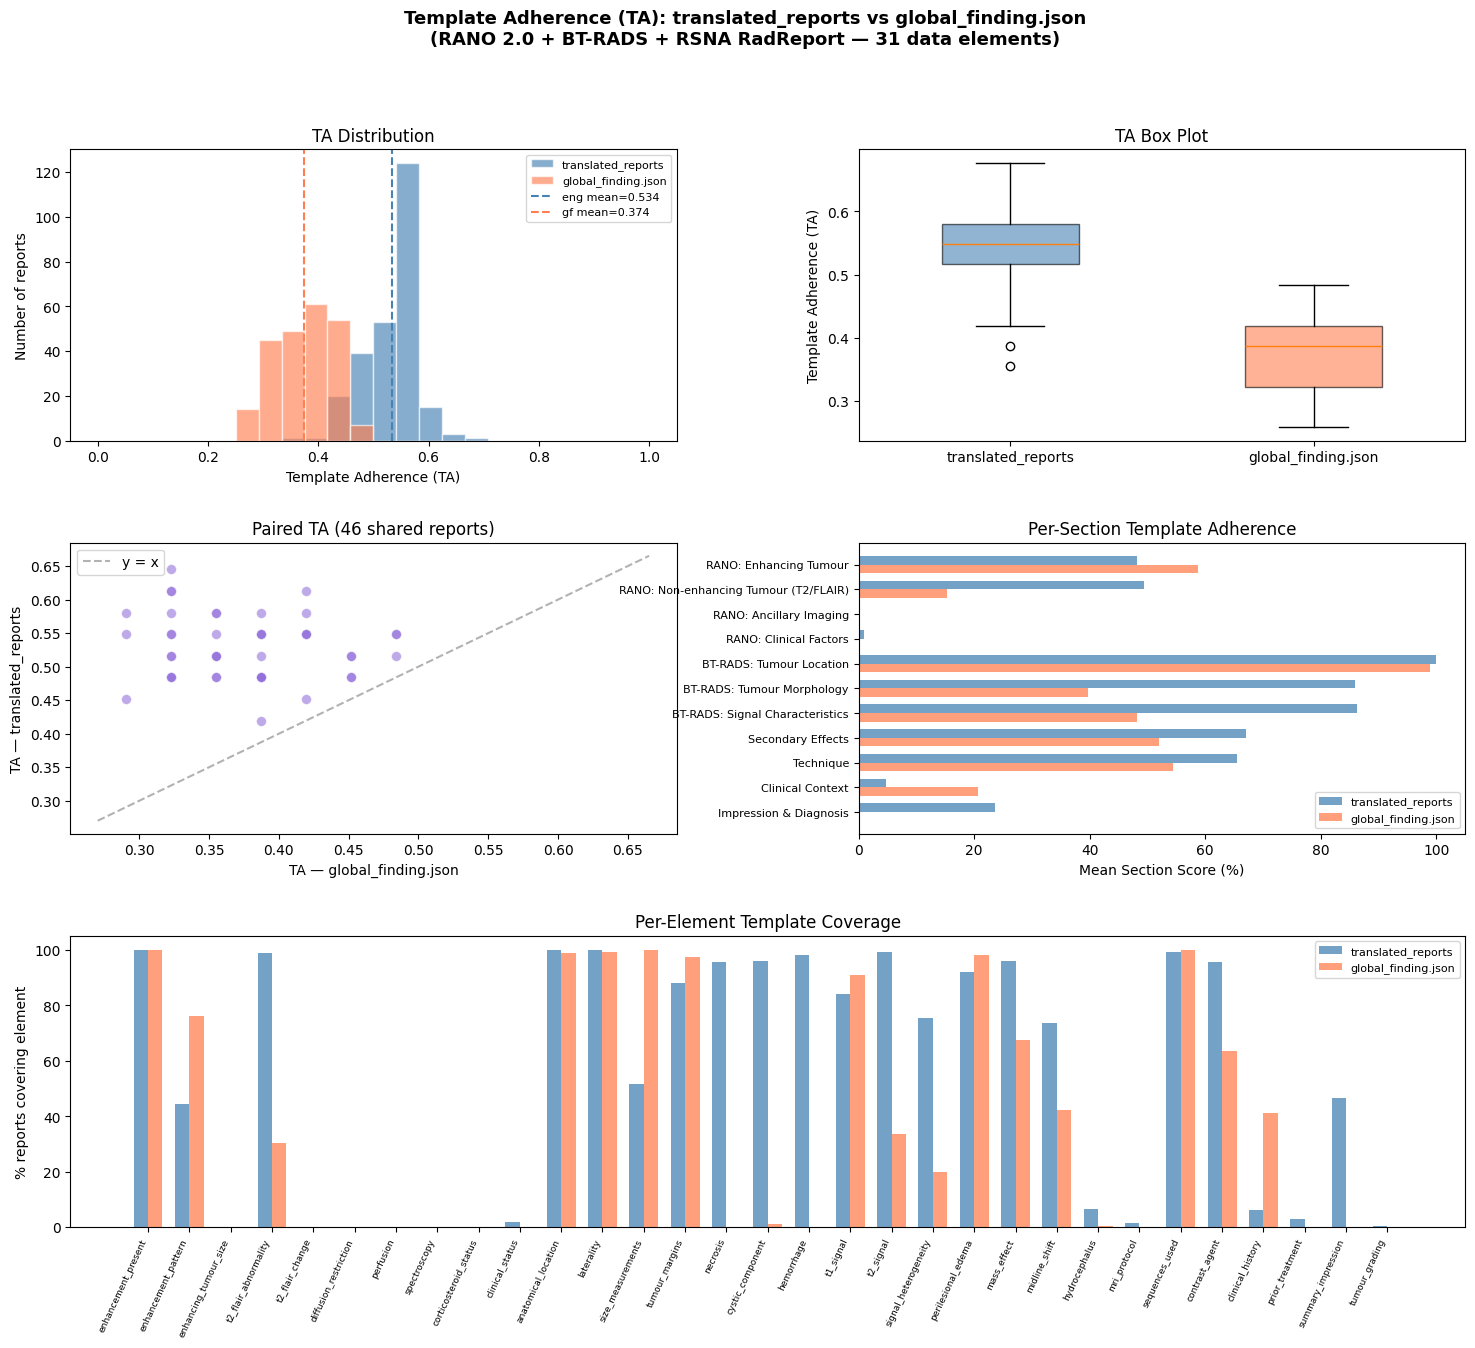


  TEMPLATE ADHERENCE (TA) SUMMARY
  Template              : 31 data elements, 11 sections
  translated_reports    : mean TA = 0.5337  (N=257)
  global_finding.json   : mean TA = 0.3743  (N=230)
  Paired Δ (eng−gf)     : +0.1529  (eng higher in 46/46 cases)


In [11]:
# =============================================
# 10) TA Analysis & Visualisation
# =============================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

ta_scores_eng = [v["ta"] for v in ta_eng.values()]
ta_scores_gf  = [v["ta"] for v in ta_gf.values()]

# ── Descriptive statistics ──
def describe_ta(values, label):
    arr = np.array(values)
    print(f"\n  {label}")
    print(f"  {'─'*50}")
    print(f"    N reports : {len(arr)}")
    print(f"    Mean TA   : {np.mean(arr):.4f}")
    print(f"    Median TA : {np.median(arr):.4f}")
    print(f"    Std       : {np.std(arr):.4f}")
    print(f"    Min       : {np.min(arr):.4f}")
    print(f"    Max       : {np.max(arr):.4f}")
    print(f"    Q1 (25%)  : {np.percentile(arr, 25):.4f}")
    print(f"    Q3 (75%)  : {np.percentile(arr, 75):.4f}")

print("=" * 65)
print("   TEMPLATE ADHERENCE (TA) — DATASET COMPARISON")
print(f"   Template: {N_TEMPLATE_ELEMENTS} data elements across "
      f"{len(BRAIN_TUMOR_TEMPLATE)} sections")
print("=" * 65)
describe_ta(ta_scores_eng, "TA — translated_reports (eng.txt)")
describe_ta(ta_scores_gf,  "TA — global_finding.json")

# ── Paired comparison ──
ta_overlap_keys = sorted(set(ta_eng.keys()) & set(ta_gf.keys()))
if ta_overlap_keys:
    ta_paired_eng = [ta_eng[k]["ta"] for k in ta_overlap_keys]
    ta_paired_gf  = [ta_gf[k]["ta"]  for k in ta_overlap_keys]
    ta_diffs = [e - g for e, g in zip(ta_paired_eng, ta_paired_gf)]
    print(f"\n  Paired comparison ({len(ta_overlap_keys)} shared reports)")
    print(f"  {'─'*50}")
    print(f"    Mean TA eng.txt      : {np.mean(ta_paired_eng):.4f}")
    print(f"    Mean TA global_find. : {np.mean(ta_paired_gf):.4f}")
    print(f"    Mean Δ (eng − gf)    : {np.mean(ta_diffs):+.4f}")
    print(f"    Median Δ             : {np.median(ta_diffs):+.4f}")
    print(f"    eng > gf             : {sum(1 for d in ta_diffs if d > 0)}/{len(ta_diffs)}")
    print(f"    eng = gf             : {sum(1 for d in ta_diffs if d == 0)}/{len(ta_diffs)}")
    print(f"    eng < gf             : {sum(1 for d in ta_diffs if d < 0)}/{len(ta_diffs)}")

# ── Per-section breakdown ──
print(f"\n{'='*65}")
print(f"   PER-SECTION TEMPLATE ADHERENCE (mean fraction covered)")
print(f"{'='*65}")
print(f"  {'Section':>30s}  {'#Elem':>6s}  {'eng.txt':>10s}  {'global_f':>10s}  {'Δ':>8s}")
print(f"  {'─'*30}  {'─'*6}  {'─'*10}  {'─'*10}  {'─'*8}")

section_names = list(BRAIN_TUMOR_TEMPLATE.keys())
sec_eng_means, sec_gf_means = [], []
for sec in section_names:
    n_elem = len(BRAIN_TUMOR_TEMPLATE[sec])
    avg_e = np.mean([v["section_scores"][sec]["score"] for v in ta_eng.values()])
    avg_g = np.mean([v["section_scores"][sec]["score"] for v in ta_gf.values()])
    sec_eng_means.append(avg_e)
    sec_gf_means.append(avg_g)
    print(f"  {sec:>30s}  {n_elem:>6d}  {avg_e:>8.1%}  {avg_g:>8.1%}  {avg_e - avg_g:>+7.1%}")

# ── Per-element breakdown ──
print(f"\n{'='*65}")
print(f"   PER-ELEMENT COVERAGE (% of reports mentioning each)")
print(f"{'='*65}")
print(f"  {'Section':>28s}  {'Element':>28s}  {'eng.txt':>9s}  {'global_f':>9s}  {'Δ':>7s}")
print(f"  {'─'*28}  {'─'*28}  {'─'*9}  {'─'*9}  {'─'*7}")
for sec, elems in BRAIN_TUMOR_TEMPLATE.items():
    for elem_name in elems:
        n_e = sum(1 for v in ta_eng.values()
                  if any(s == sec and e == elem_name
                         for s, e in v["covered_elements"]))
        n_g = sum(1 for v in ta_gf.values()
                  if any(s == sec and e == elem_name
                         for s, e in v["covered_elements"]))
        pe = 100 * n_e / len(ta_eng)
        pg = 100 * n_g / len(ta_gf)
        print(f"  {sec:>28s}  {elem_name:>28s}  {pe:>7.1f}%  {pg:>7.1f}%  {pe-pg:>+6.1f}%")

# ── Visualisation (6-panel figure) ──
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.30)

# 1) TA histogram
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)
ax1.hist(ta_scores_eng, bins=bins, alpha=0.65, label='translated_reports',
         color='steelblue', edgecolor='white')
ax1.hist(ta_scores_gf, bins=bins, alpha=0.65, label='global_finding.json',
         color='coral', edgecolor='white')
ax1.axvline(np.mean(ta_scores_eng), color='steelblue', ls='--', lw=1.5,
            label=f'eng mean={np.mean(ta_scores_eng):.3f}')
ax1.axvline(np.mean(ta_scores_gf), color='coral', ls='--', lw=1.5,
            label=f'gf mean={np.mean(ta_scores_gf):.3f}')
ax1.set_xlabel('Template Adherence (TA)')
ax1.set_ylabel('Number of reports')
ax1.set_title('TA Distribution')
ax1.legend(fontsize=8)

# 2) TA boxplot
ax2 = fig.add_subplot(gs[0, 1])
bp = ax2.boxplot([ta_scores_eng, ta_scores_gf],
                 tick_labels=['translated_reports', 'global_finding.json'],
                 patch_artist=True, widths=0.45)
bp['boxes'][0].set(facecolor='steelblue', alpha=0.6)
bp['boxes'][1].set(facecolor='coral', alpha=0.6)
ax2.set_ylabel('Template Adherence (TA)')
ax2.set_title('TA Box Plot')

# 3) Paired scatter
ax3 = fig.add_subplot(gs[1, 0])
if ta_overlap_keys:
    ax3.scatter(ta_paired_gf, ta_paired_eng, alpha=0.6, s=50,
                color='mediumpurple', edgecolors='white', lw=0.5)
    lims = [min(min(ta_paired_gf), min(ta_paired_eng)) - 0.02,
            max(max(ta_paired_gf), max(ta_paired_eng)) + 0.02]
    ax3.plot(lims, lims, 'k--', alpha=0.3, label='y = x')
    ax3.set_xlabel('TA — global_finding.json')
    ax3.set_ylabel('TA — translated_reports')
    ax3.set_title(f'Paired TA ({len(ta_overlap_keys)} shared reports)')
    ax3.legend()

# 4) Per-section grouped bar chart
ax4 = fig.add_subplot(gs[1, 1])
y = np.arange(len(section_names))
h = 0.35
ax4.barh(y - h/2, [s * 100 for s in sec_eng_means], h,
         label='translated_reports', color='steelblue', alpha=0.75)
ax4.barh(y + h/2, [s * 100 for s in sec_gf_means], h,
         label='global_finding.json', color='coral', alpha=0.75)
ax4.set_yticks(y)
ax4.set_yticklabels(section_names, fontsize=8)
ax4.set_xlabel('Mean Section Score (%)')
ax4.set_title('Per-Section Template Adherence')
ax4.legend(fontsize=8, loc='lower right')
ax4.invert_yaxis()

# 5) Per-element heatmap for eng.txt
from matplotlib.colors import LinearSegmentedColormap
elem_labels = []
elem_eng_pct, elem_gf_pct = [], []
for sec, elems in BRAIN_TUMOR_TEMPLATE.items():
    for elem_name in elems:
        elem_labels.append(f"{elem_name}")
        n_e = sum(1 for v in ta_eng.values()
                  if any(s == sec and e == elem_name for s, e in v["covered_elements"]))
        n_g = sum(1 for v in ta_gf.values()
                  if any(s == sec and e == elem_name for s, e in v["covered_elements"]))
        elem_eng_pct.append(100 * n_e / len(ta_eng))
        elem_gf_pct.append(100 * n_g / len(ta_gf))

ax5 = fig.add_subplot(gs[2, :])
x_pos = np.arange(len(elem_labels))
width = 0.35
ax5.bar(x_pos - width/2, elem_eng_pct, width, label='translated_reports',
        color='steelblue', alpha=0.75)
ax5.bar(x_pos + width/2, elem_gf_pct, width, label='global_finding.json',
        color='coral', alpha=0.75)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(elem_labels, rotation=65, ha='right', fontsize=6.5)
ax5.set_ylabel('% reports covering element')
ax5.set_title('Per-Element Template Coverage')
ax5.legend(fontsize=8)
ax5.set_ylim(0, 105)

plt.suptitle('Template Adherence (TA): translated_reports vs global_finding.json\n'
             f'(RANO 2.0 + BT-RADS + RSNA RadReport — {N_TEMPLATE_ELEMENTS} data elements)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Final summary ──
print(f"\n{'='*65}")
print(f"  TEMPLATE ADHERENCE (TA) SUMMARY")
print(f"{'='*65}")
print(f"  Template              : {N_TEMPLATE_ELEMENTS} data elements, "
      f"{len(BRAIN_TUMOR_TEMPLATE)} sections")
print(f"  translated_reports    : mean TA = {np.mean(ta_scores_eng):.4f}  "
      f"(N={len(ta_scores_eng)})")
print(f"  global_finding.json   : mean TA = {np.mean(ta_scores_gf):.4f}  "
      f"(N={len(ta_scores_gf)})")
if ta_overlap_keys:
    print(f"  Paired Δ (eng−gf)     : {np.mean(ta_diffs):+.4f}  "
          f"(eng higher in {sum(1 for d in ta_diffs if d>0)}/{len(ta_diffs)} cases)")